# 06 — Inference Pipeline

This notebook prepares the selected electricity demand forecasting model for production inference.

Objectives:
- Load the saved model and metadata
- Load historical electricity demand data
- Reproduce the required forecasting features
- Generate one-step-ahead forecasts
- Implement multi-step forecasting
- Validate that the saved model can be used independently of the training notebooks

In [1]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from pathlib import Path

PROJECT_ROOT = Path("..")

MODEL_DIR = PROJECT_ROOT / "models"

list(MODEL_DIR.iterdir())

[WindowsPath('../models/model_metadata.json'),
 WindowsPath('../models/xgboost_energy_forecaster.joblib')]

In [3]:
model_path = MODEL_DIR / "xgboost_energy_forecaster.joblib"
metadata_path = MODEL_DIR / "model_metadata.json"

model = joblib.load(model_path)

with open(metadata_path, "r") as f:
    metadata = json.load(f)

print("Model loaded:", type(model))
print("\nMetadata:")
metadata

Model loaded: <class 'xgboost.sklearn.XGBRegressor'>

Metadata:


{'model_type': 'XGBRegressor',
 'model_file': 'xgboost_energy_forecaster.joblib',
 'target': 'target',
 'forecast_horizon': '1 hour',
 'features': ['total_demand',
  'lag_1',
  'lag_2',
  'lag_3',
  'lag_24',
  'lag_48',
  'lag_168',
  'hour',
  'day_of_week',
  'is_weekend',
  'hour_sin',
  'hour_cos',
  'rolling_mean_24',
  'rolling_std_24'],
 'n_features': 14,
 'metrics': {'mae': 4606.74165656537,
  'rmse': 6790.251859292796,
  'naive_mae': 16475.71716786346,
  'naive_rmse': 24779.796900802456,
  'mae_improvement_over_naive_percent': 72.03920406238217,
  'rmse_improvement_over_naive_percent': 72.59762908277548},
 'data_split': {'method': 'chronological',
  'train_ratio': 0.8,
  'test_ratio': 0.2},
 'cross_validation': {'method': 'TimeSeriesSplit', 'n_splits': 5},
 'random_state': 42}

In [4]:
DATA_DIR = PROJECT_ROOT / "data"

for path in DATA_DIR.rglob("*"):
    if path.is_file():
        print(path)

..\data\Processed\electricity_load.parquet
..\data\Processed\hourly_demand_features.csv
..\data\Raw\LD2011_2014.txt


In [7]:
df = pd.read_csv(
    "../Data/Processed/hourly_demand_features.csv",
      parse_dates=["Unnamed: 0"]
)
print(df.shape)
print(df.columns.tolist())
df = df.rename(columns={"Unnamed: 0": "datetime"})

(34896, 16)
['Unnamed: 0', 'total_demand', 'target', 'lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_48', 'lag_168', 'hour', 'day_of_week', 'is_weekend', 'hour_sin', 'hour_cos', 'rolling_mean_24', 'rolling_std_24']


In [8]:
display(df.head())
display(df.tail())

,datetime,total_demand,target,lag_1,lag_2,lag_3,lag_24,lag_48,lag_168,hour,day_of_week,is_weekend,hour_sin,hour_cos,rolling_mean_24,rolling_std_24
0,2011-01-08 00:00:00,86403.301624,72534.984171,111609.594412,130176.983542,141034.492592,85716.807571,85490.070525,69019.423424,0,5,1,0.000000,1.000000,120015.695552,29768.012259
1,2011-01-08 01:00:00,72534.984171,69325.030607,86403.301624,111609.594412,130176.983542,73297.911807,72602.273897,66344.627687,1,5,1,0.258819,0.965926,119983.906900,29820.431514
2,2011-01-08 02:00:00,69325.030607,68554.184257,72534.984171,86403.301624,111609.594412,70543.526944,69897.630958,65981.054883,2,5,1,0.500000,0.866025,119933.136219,29909.171077
3,2011-01-08 03:00:00,68554.184257,69033.522311,69325.030607,72534.984171,86403.301624,70242.037536,69467.257186,66576.533566,3,5,1,0.707107,0.707107,119862.809000,30032.821574
4,2011-01-08 04:00:00,69033.522311,76272.763924,68554.184257,69325.030607,72534.984171,68884.017033,69493.357908,64963.552675,4,5,1,0.866025,0.500000,119869.038386,30021.801334


,datetime,total_demand,target,lag_1,lag_2,lag_3,lag_24,lag_48,lag_168,hour,day_of_week,is_weekend,hour_sin,hour_cos,rolling_mean_24,rolling_std_24
34891,2014-12-31 19:00:00,202877.313799,166951.192473,236020.817245,235987.577737,232367.180784,265611.930948,268110.871299,204783.397308,19,2,0,-0.965926,0.258819,193643.989234,50236.821452
34892,2014-12-31 20:00:00,166951.192473,156247.443652,202877.313799,236020.817245,235987.577737,253028.307138,257596.130407,179033.930691,20,2,0,-0.866025,0.500000,190057.442790,48866.841206
34893,2014-12-31 21:00:00,156247.443652,145213.196110,166951.192473,202877.313799,236020.817245,244736.400926,244650.338588,168334.167708,21,2,0,-0.707107,0.707107,186370.402903,47890.424368
34894,2014-12-31 22:00:00,145213.196110,128488.047547,156247.443652,166951.192473,202877.313799,221843.649832,224012.020251,157742.359921,22,2,0,-0.500000,0.866025,183177.467331,47976.996971
34895,2014-12-31 23:00:00,128488.047547,124214.199215,145213.196110,156247.443652,166951.192473,183987.879681,186043.226039,135369.605175,23,2,0,-0.258819,0.965926,180864.974326,49256.716328


In [9]:
print("Datetime dtype:", df["datetime"].dtype)
print("Sorted:", df["datetime"].is_monotonic_increasing)
print("Unique timestamps:", df["datetime"].is_unique)

print("\nMost common time differences:")
print(df["datetime"].diff().value_counts().head())

Datetime dtype: datetime64[ns]
Sorted: True
Unique timestamps: True

Most common time differences:
datetime
0 days 01:00:00    34895
Name: count, dtype: int64


In [10]:
model_features = metadata["features"]

print("Model expects:", len(model_features), "features")
print(model_features)

missing_features = [
    feature for feature in model_features
    if feature not in df.columns
]

extra_features = [
    column for column in df.columns
    if column not in model_features + ["datetime", "target"]
]

print("\nMissing features:", missing_features)
print("Extra non-model columns:", extra_features)

Model expects: 14 features
['total_demand', 'lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_48', 'lag_168', 'hour', 'day_of_week', 'is_weekend', 'hour_sin', 'hour_cos', 'rolling_mean_24', 'rolling_std_24']

Missing features: []
Extra non-model columns: []


In [11]:
assert not missing_features, f"Missing model features: {missing_features}"

print("\nAll required model features are present.")


All required model features are present.


In [12]:
feature_missing = df[model_features].isna().sum()

print(feature_missing)
print("Total missing feature values:", feature_missing.sum())

total_demand       0
lag_1              0
lag_2              0
lag_3              0
lag_24             0
lag_48             0
lag_168            0
hour               0
day_of_week        0
is_weekend         0
hour_sin           0
hour_cos           0
rolling_mean_24    0
rolling_std_24     0
dtype: int64
Total missing feature values: 0


## 5. One-Step Forecast

Test the saved model on an existing feature row and compare its prediction with the known target value.

In [13]:
X = df[model_features]
y = df["target"]

predictions = model.predict(X)

df["prediction"] = predictions

display(
    df[
        ["datetime", "target", "prediction"]
    ].tail(10)
)

,datetime,target,prediction
34886,2014-12-31 14:00:00,237544.997937,238213.234375
34887,2014-12-31 15:00:00,232367.180784,239843.765625
34888,2014-12-31 16:00:00,235987.577737,237435.734375
34889,2014-12-31 17:00:00,236020.817245,250025.250000
34890,2014-12-31 18:00:00,202877.313799,229454.687500
34891,2014-12-31 19:00:00,166951.192473,175846.281250
34892,2014-12-31 20:00:00,156247.443652,145367.281250
34893,2014-12-31 21:00:00,145213.196110,148770.937500
34894,2014-12-31 22:00:00,128488.047547,125838.562500
34895,2014-12-31 23:00:00,124214.199215,102656.062500


In [14]:
df["absolute_error"] = np.abs(
    df["target"] - df["prediction"]
)

print("MAE:", df["absolute_error"].mean())

MAE: 2787.7623200841826


In [15]:
latest_features = df[model_features].iloc[[-1]]

single_prediction = model.predict(latest_features)[0]

print("Prediction:", single_prediction)
print("Actual target:", df["target"].iloc[-1])

Prediction: 102656.06
Actual target: 124214.199215235


In [17]:
def forecast_demand(history, model, horizon=24):
    """
    Generate recursive electricity-demand forecasts.

    Parameters
    ----------
    history : pandas.Series
        Historical hourly total demand with a DatetimeIndex.
    model : trained forecasting model
        Saved XGBoost forecasting model.
    horizon : int
        Number of future hours to forecast.

    Returns
    -------
    pandas.DataFrame
        Forecasts indexed by future datetime.
    """

    history = history.copy()

    if not isinstance(history.index, pd.DatetimeIndex):
        raise TypeError("history must have a DatetimeIndex.")

    if history.index.has_duplicates:
        raise ValueError("History contains duplicate timestamps.")

    history = history.sort_index()

    if len(history) < 168:
        raise ValueError(
            "At least 168 historical observations are required."
        )

    if not history.index.to_series().diff().iloc[1:].eq(
        pd.Timedelta(hours=1)
    ).all():
        raise ValueError("History must contain continuous hourly observations.")

    values = history.astype(float).tolist()
    timestamps = history.index.tolist()

    forecasts = []

    for _ in range(horizon):

        next_timestamp = timestamps[-1] + pd.Timedelta(hours=1)

        lag_1 = values[-1]
        lag_2 = values[-2]
        lag_3 = values[-3]
        lag_24 = values[-24]
        lag_48 = values[-48]
        lag_168 = values[-168]

        rolling_values = values[-24:]

        rolling_mean_24 = np.mean(rolling_values)
        rolling_std_24 = np.std(rolling_values, ddof=1)

        hour = next_timestamp.hour
        day_of_week = next_timestamp.dayofweek
        is_weekend = int(day_of_week >= 5)

        hour_sin = np.sin(2 * np.pi * hour / 24)
        hour_cos = np.cos(2 * np.pi * hour / 24)

        features = pd.DataFrame([{
            "total_demand": values[-1],
            "lag_1": lag_1,
            "lag_2": lag_2,
            "lag_3": lag_3,
            "lag_24": lag_24,
            "lag_48": lag_48,
            "lag_168": lag_168,
            "hour": hour,
            "day_of_week": day_of_week,
            "is_weekend": is_weekend,
            "hour_sin": hour_sin,
            "hour_cos": hour_cos,
            "rolling_mean_24": rolling_mean_24,
            "rolling_std_24": rolling_std_24
        }])

        features = features[model_features]

        prediction = float(model.predict(features)[0])

        timestamps.append(next_timestamp)
        values.append(prediction)

        forecasts.append({
            "datetime": next_timestamp,
            "forecast": prediction
        })

    return pd.DataFrame(forecasts)

## 7. Generate a 24-Hour Forecast

Use the most recent historical demand observations to generate forecasts for the next 24 hours.

In [18]:
history = (
    df
    .set_index("datetime")["total_demand"]
    .sort_index()
)

forecast_24h = forecast_demand(
    history=history,
    model=model,
    horizon=24
)

display(forecast_24h)

,datetime,forecast
0,2015-01-01 00:00:00,106385.953125
1,2015-01-01 01:00:00,102445.757812
2,2015-01-01 02:00:00,98362.875000
3,2015-01-01 03:00:00,96506.335938
4,2015-01-01 04:00:00,100209.195312
5,2015-01-01 05:00:00,108527.351562
6,2015-01-01 06:00:00,126263.921875
7,2015-01-01 07:00:00,134570.953125
8,2015-01-01 08:00:00,168384.031250
9,2015-01-01 09:00:00,207924.765625


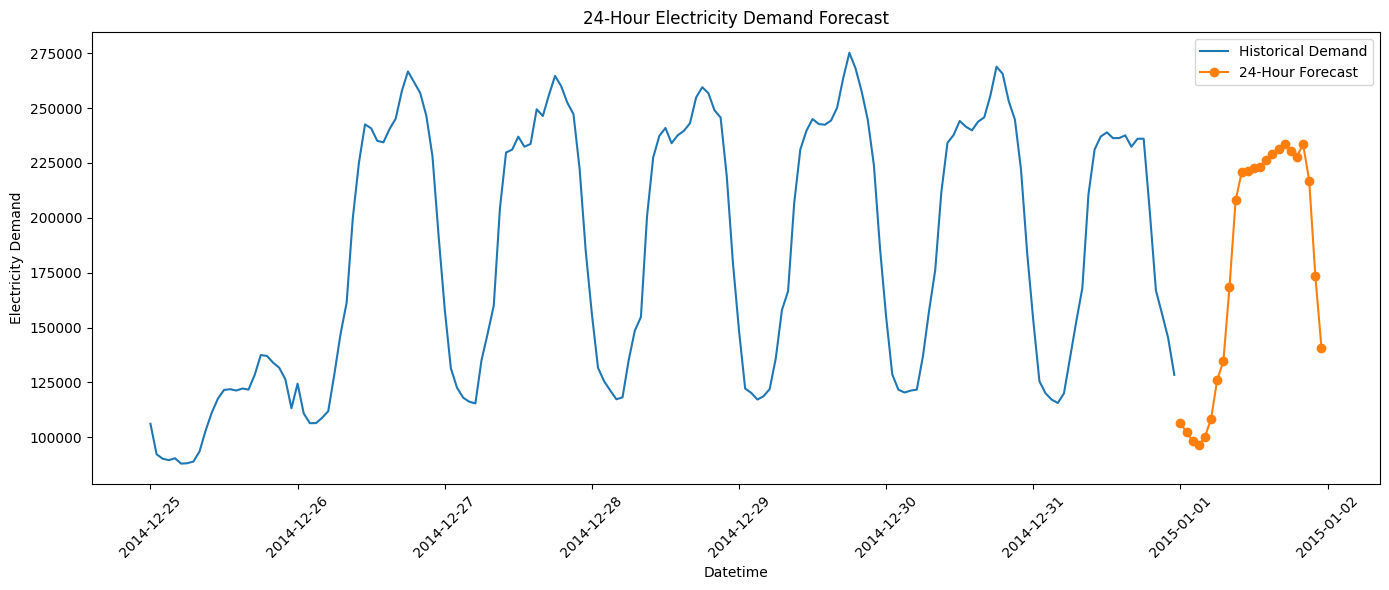

In [19]:
plt.figure(figsize=(14, 6))

recent_history = history.tail(168)

plt.plot(
    recent_history.index,
    recent_history.values,
    label="Historical Demand"
)

plt.plot(
    forecast_24h["datetime"],
    forecast_24h["forecast"],
    marker="o",
    label="24-Hour Forecast"
)

plt.xlabel("Datetime")
plt.ylabel("Electricity Demand")
plt.title("24-Hour Electricity Demand Forecast")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
print("Forecast rows:", len(forecast_24h))
print("Missing forecasts:", forecast_24h["forecast"].isna().sum())
print(
    "Forecast timestamps continuous:",
    forecast_24h["datetime"].diff().iloc[1:].eq(
        pd.Timedelta(hours=1)
    ).all()
)

Forecast rows: 24
Missing forecasts: 0
Forecast timestamps continuous: True


In [21]:
assert len(forecast_24h) == 24
assert forecast_24h["forecast"].notna().all()
assert forecast_24h["datetime"].is_unique

print("24-hour forecast validation passed.")

24-hour forecast validation passed.


In [22]:
FORECAST_DIR = PROJECT_ROOT / "data" / "Processed" / "forecasts"

FORECAST_DIR.mkdir(parents=True, exist_ok=True)

forecast_path = FORECAST_DIR / "sample_24h_forecast.csv"

forecast_24h.to_csv(
    forecast_path,
    index=False
)

print("Forecast saved to:", forecast_path)

Forecast saved to: ..\data\Processed\forecasts\sample_24h_forecast.csv


In [23]:
print("=" * 50)
print("INFERENCE PIPELINE VALIDATION")
print("=" * 50)

print(f"Model: {metadata['model_type']}")
print(f"Forecast horizon tested: 24 hours")
print(f"Required features: {metadata['n_features']}")
print(f"Forecast rows generated: {len(forecast_24h)}")
print(
    f"Forecast range: "
    f"{forecast_24h['datetime'].min()} "
    f"→ "
    f"{forecast_24h['datetime'].max()}"
)

print("\nInference pipeline completed successfully.")

INFERENCE PIPELINE VALIDATION
Model: XGBRegressor
Forecast horizon tested: 24 hours
Required features: 14
Forecast rows generated: 24
Forecast range: 2015-01-01 00:00:00 → 2015-01-01 23:00:00

Inference pipeline completed successfully.
